In [376]:
"""
READ DF
"""
import pandas as pd

df = pd.read_csv("countries.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 70 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            264 non-null    float64
 5   1961            264 non-null    float64
 6   1962            264 non-null    float64
 7   1963            264 non-null    float64
 8   1964            264 non-null    float64
 9   1965            264 non-null    float64
 10  1966            264 non-null    float64
 11  1967            264 non-null    float64
 12  1968            264 non-null    float64
 13  1969            264 non-null    float64
 14  1970            264 non-null    float64
 15  1971            264 non-null    float64
 16  1972            264 non-null    float64
 17  1973            264 non-null    flo

In [377]:
"""
SEE THEMES FOR MATPLOTLIB
"""

import matplotlib.style as st

st.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

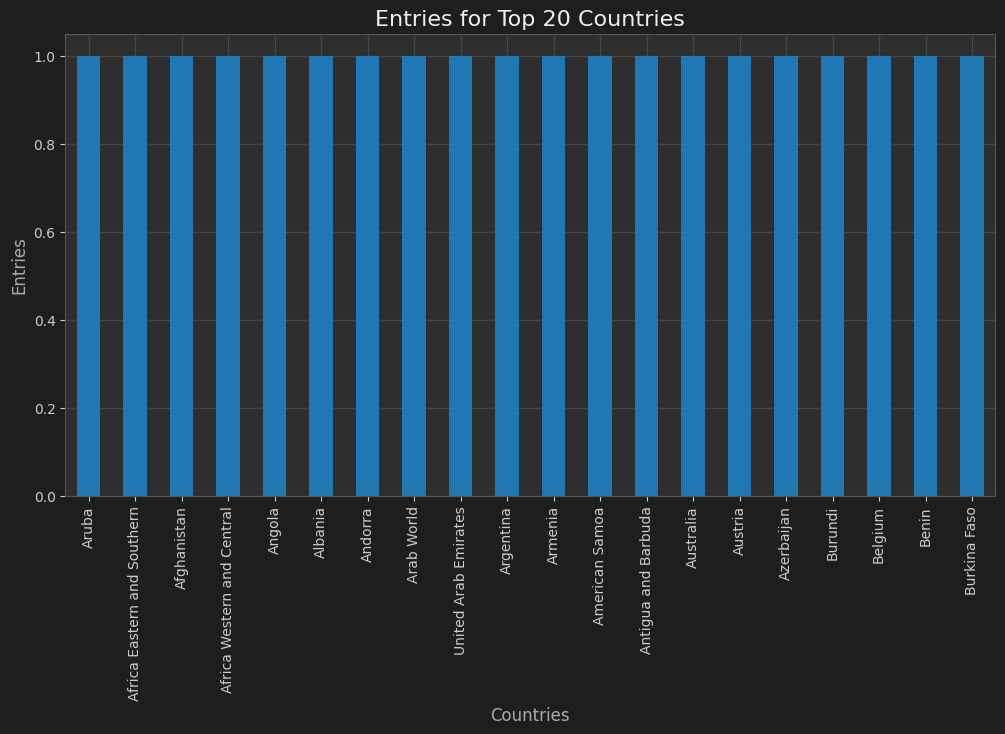

In [378]:
"""
SET THEME
"""

import matplotlib.pyplot as plt
from cycler import cycler

plt.style.use('dark_background')

plt.rcParams.update({
    'axes.facecolor': '#2E2E2E',
    'figure.facecolor': '#1E1E1E',
    'axes.edgecolor': '#555555',
    'axes.labelcolor': '#AAAAAA',
    'xtick.color': '#CCCCCC',
    'ytick.color': '#CCCCCC',
    'grid.color': '#444444',
    'text.color': '#EEEEEE'
})

plt.rcParams['axes.prop_cycle'] = cycler(color=[
    '#1f77b4',
    '#ff7f0e',
    '#2ca02c',
    "#e05151",
    '#9467bd', 
    '#8c564b',
    '#e377c2', 
    '#7f7f7f',
    '#bcbd22',
    '#17becf'
])


"""
BAR CHART
"""
counts = df["Country Name"].value_counts().head(20)

plt.figure(figsize=(12,6))
counts.plot(kind="bar")
plt.title("Entries for Top 20 Countries")
plt.xlabel("Countries")
plt.ylabel("Entries")
plt.show()

In [379]:
# find which countries have any nulls in year columns

years = [str(y) for y in range(1960,2025)]

null_countries=df[df[years].isnull().any(axis=1)]

null_countries[["Country Name", "Indicator Name"]+years]

,Country Name,Indicator Name,1960,1961,1962,1963,1964,1965,1966,1967,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
110,Not classified,"Population, total",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
196,West Bank and Gaza,"Population, total",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"4,270,092","4,367,088","4,454,805","4,569,087","4,685,306","4,803,269","4,922,749","5,043,612","5,165,775","5,289,152"


In [380]:
# Drop the null row and fill WBG's null values with the oldest population count available
df = df.drop(index=110)

gaza_row=df[df["Country Name"]=="West Bank and Gaza"]

df.loc[df["Country Name"] == "West Bank and Gaza", years] = gaza_row[years].fillna(0)

In [381]:
null_countries=df[df[years].isnull().any(axis=1)]

null_countries[["Country Name", "Indicator Name"]+years]

,Country Name,Indicator Name,1960,1961,1962,1963,1964,1965,1966,1967,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024


In [382]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 265 entries, 0 to 265
Data columns (total 70 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    265 non-null    object 
 1   Country Code    265 non-null    object 
 2   Indicator Name  265 non-null    object 
 3   Indicator Code  265 non-null    object 
 4   1960            265 non-null    float64
 5   1961            265 non-null    float64
 6   1962            265 non-null    float64
 7   1963            265 non-null    float64
 8   1964            265 non-null    float64
 9   1965            265 non-null    float64
 10  1966            265 non-null    float64
 11  1967            265 non-null    float64
 12  1968            265 non-null    float64
 13  1969            265 non-null    float64
 14  1970            265 non-null    float64
 15  1971            265 non-null    float64
 16  1972            265 non-null    float64
 17  1973            265 non-null    float64


In [383]:
"""
DROP UNUSED COLUMNS
"""

df.drop(columns=["Indicator Name","Indicator Code", "Unnamed: 69"], inplace=True)

print(df.iloc[[0, 17, 34, 51, 68]])

                Country Name Country Code        1960        1961        1962  \
0                      Aruba          ABW      54,922      55,578      56,320   
17                   Belgium          BEL   9,153,489   9,183,948   9,220,578   
34  Central African Republic          CAF   1,702,346   1,734,580   1,768,115   
51                   Curacao          CUW     124,826     126,125     128,414   
68                 Euro area          EMU 270,148,970 272,472,951 274,815,182   

          1963        1964        1965        1966        1967  ...  \
0       57,002      57,619      58,190      58,694      58,990  ...   
17   9,289,770   9,378,113   9,463,667   9,527,807   9,580,991  ...   
34   1,803,063   1,839,583   1,877,854   1,918,082   1,960,444  ...   
51     130,860     133,148     135,266     136,682     138,140  ...   
68 277,205,348 279,621,056 282,028,347 284,299,197 286,298,506  ...   

          2015        2016        2017        2018        2019        2020  \
0      1

In [384]:
"""
CHECK FOR NULLS
"""
df.columns[df.isna().any()]

Index([], dtype='object')

In [385]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 265 entries, 0 to 265
Data columns (total 67 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  265 non-null    object 
 1   Country Code  265 non-null    object 
 2   1960          265 non-null    float64
 3   1961          265 non-null    float64
 4   1962          265 non-null    float64
 5   1963          265 non-null    float64
 6   1964          265 non-null    float64
 7   1965          265 non-null    float64
 8   1966          265 non-null    float64
 9   1967          265 non-null    float64
 10  1968          265 non-null    float64
 11  1969          265 non-null    float64
 12  1970          265 non-null    float64
 13  1971          265 non-null    float64
 14  1972          265 non-null    float64
 15  1973          265 non-null    float64
 16  1974          265 non-null    float64
 17  1975          265 non-null    float64
 18  1976          265 non-null    float

In [386]:
"""
GET TOP 20
"""
top20countries = df.nlargest(20, "2024")
print(top20countries[["Country Name","2024"]])

                                    Country Name          2024
259                                        World 8,142,056,446
103                             IDA & IBRD total 6,926,456,321
140                          Low & middle income 6,563,719,861
156                                Middle income 5,939,111,763
102                                    IBRD only 4,979,720,059
62                    Early-demographic dividend 3,552,278,604
139                          Lower middle income 3,120,983,658
249                          Upper middle income 2,818,128,105
63                           East Asia & Pacific 2,388,378,491
142                    Late-demographic dividend 2,328,890,789
61   East Asia & Pacific (excluding high income) 2,141,122,258
230   East Asia & Pacific (IDA & IBRD countries) 2,114,653,077
104                                    IDA total 1,946,736,262
204                                   South Asia 1,677,384,532
240                      South Asia (IDA & IBRD) 1,677,

In [387]:
"""
MAKE POPULATIONS READABLE
"""

pd.options.display.float_format = '{:,.0f}'.format


df[years] = df[years].apply(lambda col: col.map(lambda x: f"{x:,.0f}"))


In [388]:
df[["Country Name","1970","1990","2024"]].head()

,Country Name,1970,1990,2024
0,Aruba,"58,950","62,753","107,624"
1,Africa Eastern and Southern,"171,984,985","311,748,681","769,294,618"
2,Afghanistan,"11,290,128","12,045,660","42,647,492"
3,Africa Western and Central,"122,086,536","209,566,031","521,764,076"
4,Angola,"5,852,788","11,626,360","37,885,849"


In [389]:
countries = df["Country Name"].tolist()
countries

['Aruba',
 'Africa Eastern and Southern',
 'Afghanistan',
 'Africa Western and Central',
 'Angola',
 'Albania',
 'Andorra',
 'Arab World',
 'United Arab Emirates',
 'Argentina',
 'Armenia',
 'American Samoa',
 'Antigua and Barbuda',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Burundi',
 'Belgium',
 'Benin',
 'Burkina Faso',
 'Bangladesh',
 'Bulgaria',
 'Bahrain',
 'Bahamas, The',
 'Bosnia and Herzegovina',
 'Belarus',
 'Belize',
 'Bermuda',
 'Bolivia',
 'Brazil',
 'Barbados',
 'Brunei Darussalam',
 'Bhutan',
 'Botswana',
 'Central African Republic',
 'Canada',
 'Central Europe and the Baltics',
 'Switzerland',
 'Channel Islands',
 'Chile',
 'China',
 "Cote d'Ivoire",
 'Cameroon',
 'Congo, Dem. Rep.',
 'Congo, Rep.',
 'Colombia',
 'Comoros',
 'Cabo Verde',
 'Costa Rica',
 'Caribbean small states',
 'Cuba',
 'Curacao',
 'Cayman Islands',
 'Cyprus',
 'Czechia',
 'Germany',
 'Djibouti',
 'Dominica',
 'Denmark',
 'Dominican Republic',
 'Algeria',
 'East Asia & Pacific (excluding high income)

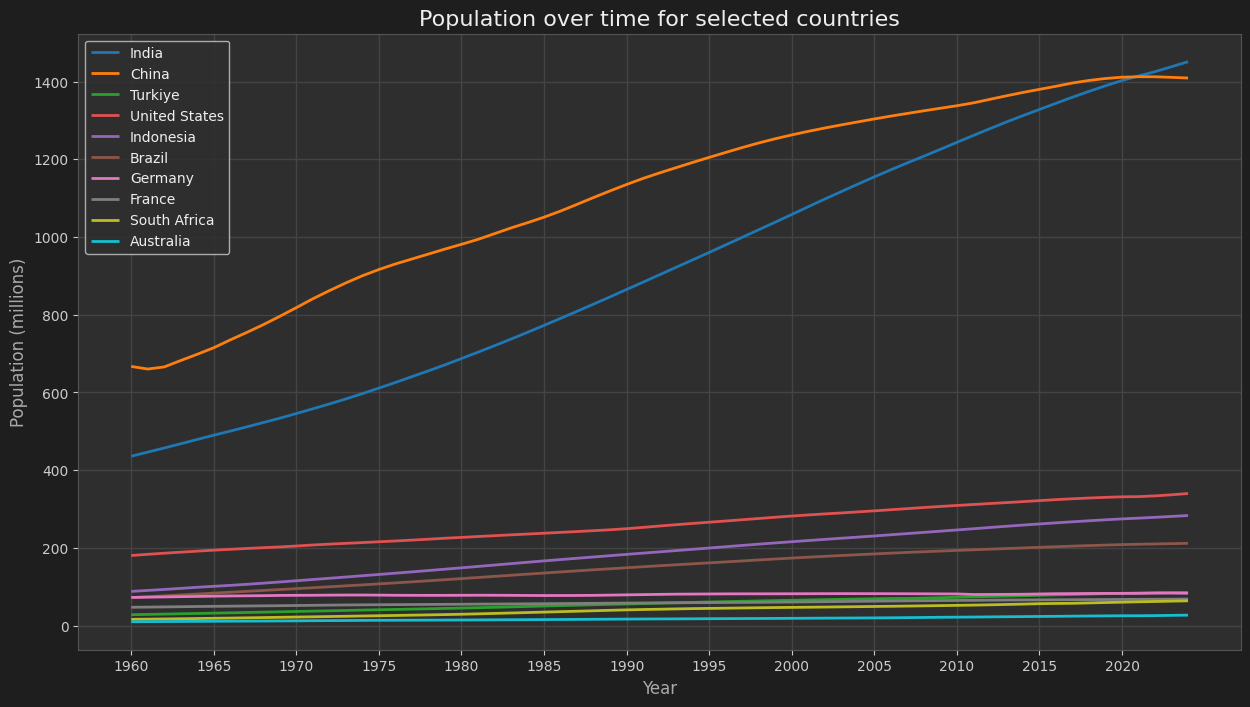

In [390]:
"""
SPECIFIC COUNTRIES' POPULATION IN YEARS
"""

plt.figure(figsize=(15,8))

countries = [
    "India", "China", "Turkiye", "United States", "Indonesia",
    "Brazil", "Germany", "France", "South Africa", "Australia"
]

# turn years into integer
df[years] = df[years].replace({',': ''}, regex=True).astype(float)

for country in countries:
    # get row:
    row = df[df["Country Name"]==country]
    # get year values:
    population = row[years].values.flatten()
    # add to the plot with years (x), population (y) after population is normalised
    plt.plot(years, population/1e6, label=country)

plt.xlabel("Year")
plt.ylabel("Population (millions)")
plt.title("Population over time for selected countries")
plt.xticks(ticks=range(0,len(years),5))
plt.legend()
plt.show()


In [391]:
"""
FASTEST GROWING COUNTRIES
"""

countries_only = [
    'Aruba','Afghanistan','Albania','Andorra','United Arab Emirates','Argentina','Armenia',
    'American Samoa','Antigua and Barbuda','Australia','Austria','Azerbaijan','Angola','Belgium',
    'Benin','Burkina Faso','Bangladesh','Bulgaria','Bahrain','Bahamas, The','Bosnia and Herzegovina',
    'Belarus','Belize','Bermuda','Bolivia','Brazil','Barbados','Brunei Darussalam','Bhutan','Botswana',
    'Central African Republic','Canada','Switzerland','Channel Islands','Chile','China',"Cote d'Ivoire",
    'Cameroon','Congo, Dem. Rep.','Congo, Rep.','Colombia','Comoros','Cabo Verde','Costa Rica','Cuba',
    'Curacao','Cayman Islands','Cyprus','Czechia','Germany','Djibouti','Dominica','Denmark',
    'Algeria','Ecuador','Egypt, Arab Rep.','Eritrea','Spain','Estonia','Ethiopia','Finland','Fiji','France',
    'Faroe Islands','Micronesia, Fed. Sts.','Gabon','United Kingdom','Georgia','Ghana','Gibraltar',
    'Guinea','Gambia, The','Guinea-Bissau','Equatorial Guinea','Greece','Grenada','Greenland','Guatemala',
    'Guam','Hong Kong SAR, China','Honduras','Croatia','Haiti','Hungary','Indonesia','India','Ireland',
    'Iran, Islamic Rep.','Iraq','Iceland','Israel','Italy','Jamaica','Jordan','Japan','Kazakhstan','Kenya',
    'Kyrgyz Republic','Cambodia','Kiribati','St. Kitts and Nevis','Korea, Rep.','Kuwait','Lao PDR',
    'Lebanon','Liberia','Libya','St. Lucia','Liechtenstein','Sri Lanka','Lesotho','Lithuania','Luxembourg',
    'Latvia','Macao SAR, China','St. Martin (French part)','Morocco','Monaco','Moldova','Madagascar',
    'Maldives','Mexico','Marshall Islands','Montenegro','Mongolia','Northern Mariana Islands','Mozambique',
    'Mauritania','Mauritius','Malawi','Malaysia','North Macedonia','Mali','Malta','Myanmar','Namibia',
    'New Caledonia','Niger','Nigeria','Nicaragua','Netherlands','Norway','Nepal','Nauru','New Zealand',
    'Oman','Pakistan','Panama','Peru','Philippines','Palau','Papua New Guinea','Poland','Puerto Rico (US)',
    "Korea, Dem. People's Rep.",'Portugal','Paraguay','West Bank and Gaza','French Polynesia','Qatar',
    'Romania','Russian Federation','Saudi Arabia','Senegal','Singapore','Solomon Islands','Sierra Leone',
    'El Salvador','San Marino','Somalia','Serbia','Sao Tome and Principe','Suriname','Slovak Republic',
    'Slovenia','Sweden','Eswatini','Sint Maarten (Dutch part)','Seychelles','Syrian Arab Republic',
    'Turks and Caicos Islands','Togo','Thailand','Tajikistan','Turkmenistan','Timor-Leste','Tonga',
    'Trinidad and Tobago','Tunisia','Turkiye','Tuvalu','Tanzania','Uganda','Ukraine','Uruguay',
    'United States','Uzbekistan','St. Vincent and the Grenadines','Venezuela, RB','British Virgin Islands',
    'Virgin Islands (U.S.)','Viet Nam','Vanuatu','Samoa','Kosovo','Yemen, Rep.','South Africa','Zambia','Zimbabwe',
    "Burundi","Guyana","Rwanda","Sudan", "Chad", 'Dominican Republic', 'Caribbean small states',
    'Other small states'
]

df_countries = df[df["Country Name"].isin(countries_only)].copy()

df_countries["Population Increase"] = df_countries["2024"]-df_countries["1960"]

top_growth = df_countries.sort_values(by="Population Increase", ascending=False).head(10)
top_growth[["Country Name","1960","1990","2024","Population Increase"]]

,Country Name,1960,1990,2024,Population Increase
109,India,"435,990,338","864,972,221","1,450,935,791","1,014,945,453"
40,China,"667,070,000","1,135,185,000","1,408,975,000","741,905,000"
184,Pakistan,"45,709,310","116,155,576","251,269,164","205,559,854"
106,Indonesia,"88,296,070","183,501,098","283,487,931","195,191,861"
174,Nigeria,"45,053,782","97,120,925","232,679,478","187,625,696"
251,United States,"180,671,000","249,623,000","340,110,988","159,439,988"
29,Brazil,"72,388,126","149,143,223","211,998,573","139,610,447"
20,Bangladesh,"51,828,660","111,633,717","173,562,364","121,733,704"
72,Ethiopia,"21,376,693","47,609,755","132,059,767","110,683,074"
154,Mexico,"36,724,615","82,820,170","130,861,007","94,136,392"


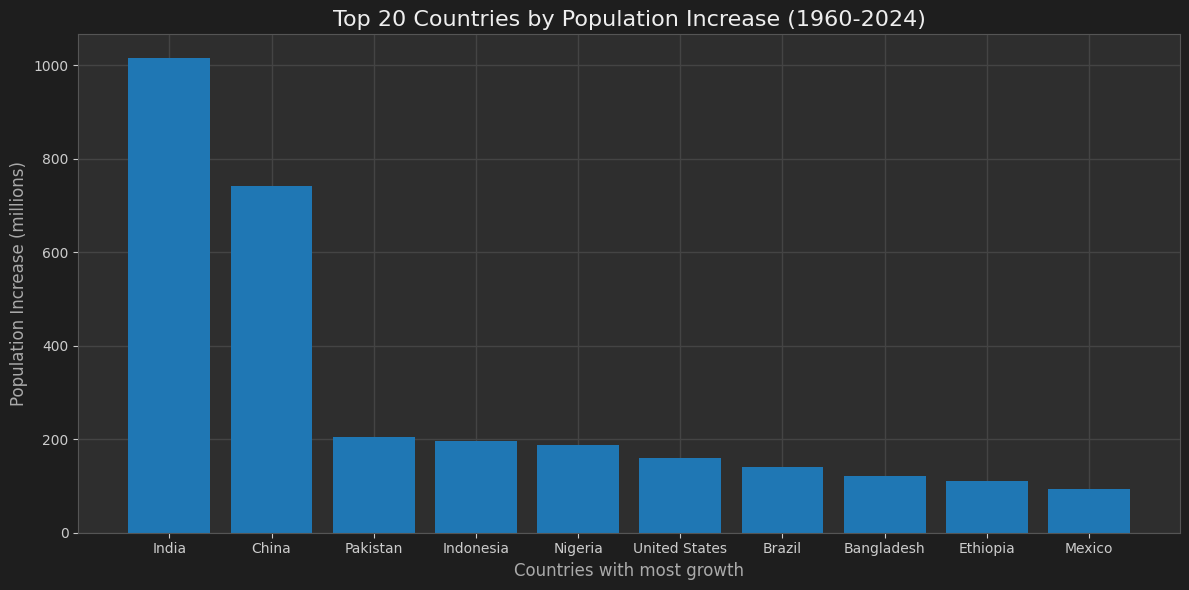

In [392]:
"""
TOP 20 GROWING COUNTRIES
"""

pop_inc_mil = top_growth["Population Increase"] / 1_000_000

plt.figure(figsize=(12, 6))
plt.bar(top_growth["Country Name"], pop_inc_mil)
plt.ylabel("Population Increase (millions)")
plt.xlabel("Countries with most growth")
plt.title("Top 20 Countries by Population Increase (1960-2024)")
plt.tight_layout()
plt.show()


In [393]:
"""
SEE NON-COUNTRY DATA
"""
df_noncountries=df[~df["Country Name"].isin(countries_only)]

regions = df_noncountries["Country Name"].tolist()
regions

['Africa Eastern and Southern',
 'Africa Western and Central',
 'Arab World',
 'Central Europe and the Baltics',
 'East Asia & Pacific (excluding high income)',
 'Early-demographic dividend',
 'East Asia & Pacific',
 'Europe & Central Asia (excluding high income)',
 'Europe & Central Asia',
 'Euro area',
 'European Union',
 'Fragile and conflict affected situations',
 'High income',
 'Heavily indebted poor countries (HIPC)',
 'IBRD only',
 'IDA & IBRD total',
 'IDA total',
 'IDA blend',
 'IDA only',
 'Isle of Man',
 'Latin America & Caribbean (excluding high income)',
 'Latin America & Caribbean',
 'Least developed countries: UN classification',
 'Low income',
 'Lower middle income',
 'Low & middle income',
 'Late-demographic dividend',
 'Middle East, North Africa, Afghanistan & Pakistan',
 'Middle income',
 'Middle East, North Africa, Afghanistan & Pakistan (excluding high income)',
 'North America',
 'OECD members',
 'Pre-demographic dividend',
 'Pacific island small states',
 'Post-

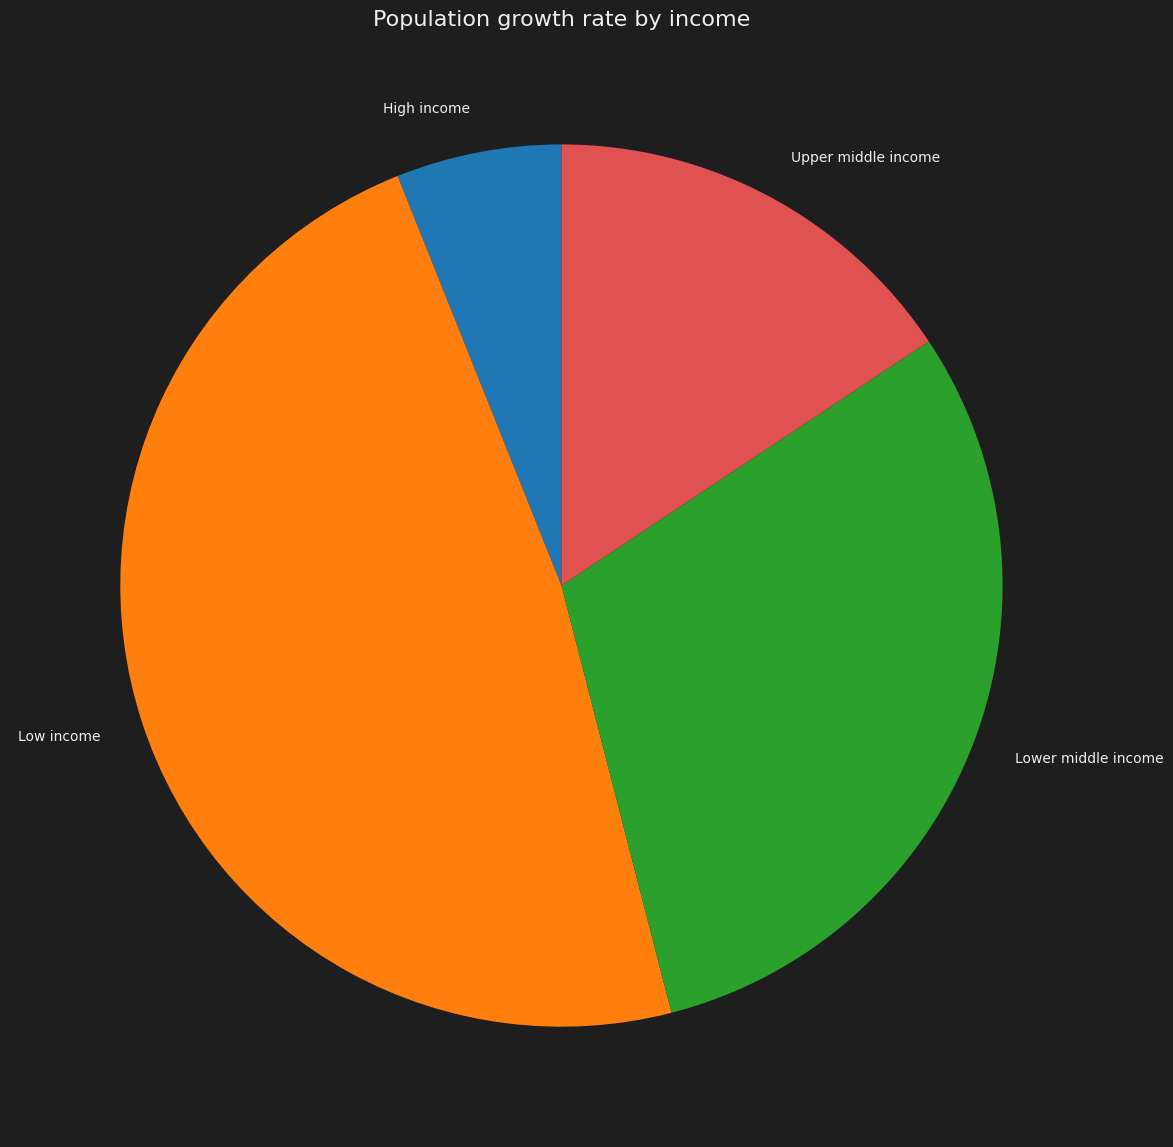

In [394]:
"""
PIE CHART OF GROWTH RATE BASED ON INCOME
"""

income_groups=["Low income","Lower middle income","Upper middle income","High income"]
df_income = df[df["Country Name"].isin(income_groups)].copy()

df_income["Growth Rate"] = ((df_income["2024"]-df_income["1960"])/df_income["1960"])*100

plt.figure(figsize=(12,12))

plt.pie(df_income["Growth Rate"],
        labels=df_income["Country Name"],
        startangle=90)
plt.title("Population growth rate by income")
plt.tight_layout()
plt.show()

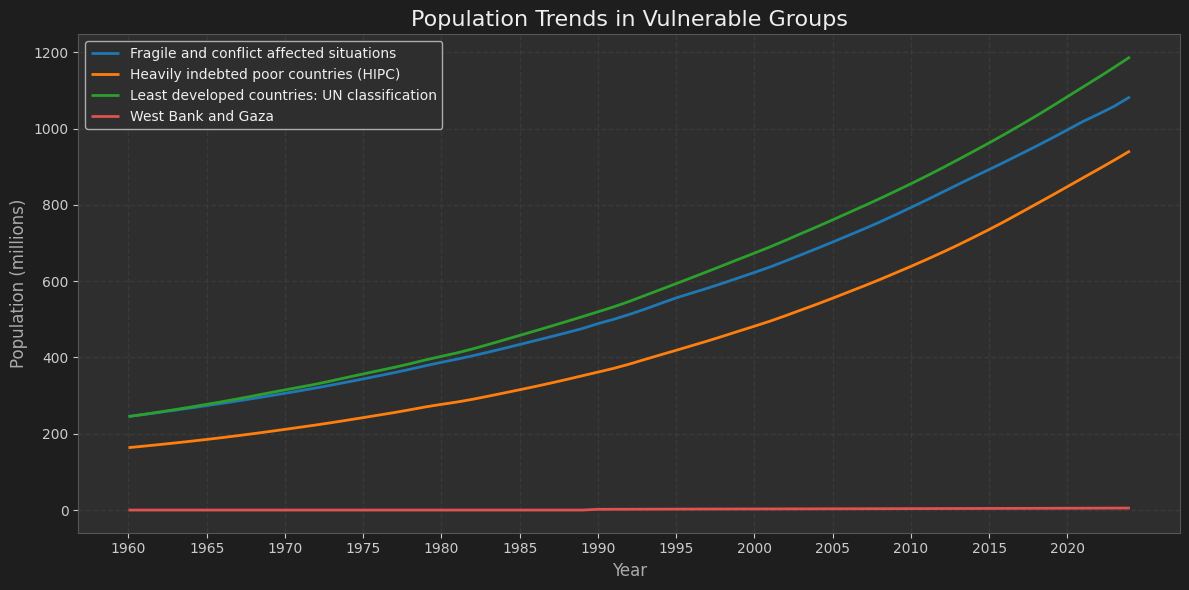

In [396]:
"""
VULNERABLE AREAS
"""

categories = [
    'Fragile and conflict affected situations',
    'Heavily indebted poor countries (HIPC)',
    'Least developed countries: UN classification',
    'West Bank and Gaza'
]

plt.figure(figsize=(12,6))

for category in categories:
    row = df[df["Country Name"]==category]
    plt.plot(years, row[years].values.flatten()/1e6, label=category)

plt.xlabel("Year")
plt.ylabel("Population (millions)")
plt.title("Population Trends in Vulnerable Groups")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(ticks=range(0,len(years),5))
plt.tight_layout()
plt.show()